# 1 Load the Customer Segmentation Tutorial Dataset from Kaggle into a Jupyter Notebook and display the first 10 rows using pandas.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Mall_Customers.csv")
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


# 2 Use pandas to check for missing values in the Age, Annual Income, and Spending Score columns, and print the total number of missing values for each.


In [4]:
missing_values = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


# 3. Create a scatterplot of Annual Income vs Spending Score using matplotlib or seaborn to visualize how customers are distributed.<br><br><em><strong>Hint:</strong> Use seaborn.scatterplot() or plt.scatter().</em>

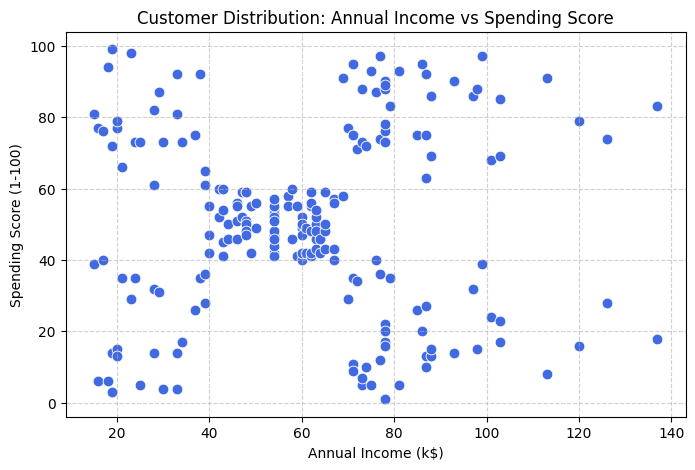

In [5]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', color='royalblue', s=60)

plt.title('Customer Distribution: Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 4. Generate a heatmap of the correlation matrix for the numerical features in the dataset using seaborn, and interpret which two features are most strongly correlated.

In [6]:
numerical_cols = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
corr_matrix = numerical_cols.corr()

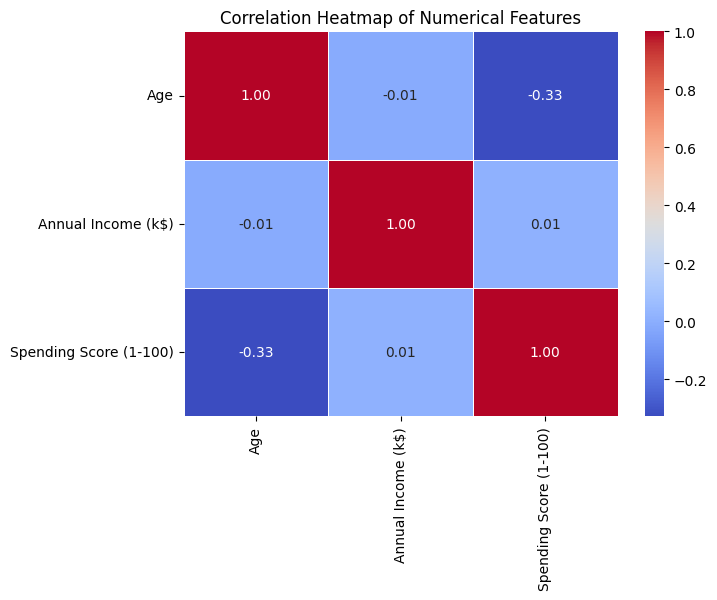

In [7]:
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

Looking at the heatmap, the strongest correlation (though still relatively weak) is between Age and Spending Score, which is roughly -0.33. This negative correlation indicates that as a customer's age increases, their spending score tends to decrease slightly. Annual Income has almost zero correlation with Age or Spending Score.

# 5. Apply K-Means clustering (from sklearn.cluster) to segment customers into 3 groups based on Annual Income and Spending Score, then add a new column 'Cluster' to your DataFrame with the assigned cluster for each customer.<br><br><em><strong>Constraint:</strong> Use only the two features for clustering, and set random_state=42 for reproducibility.</em>

In [8]:
from sklearn.cluster import KMeans

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')

df['Cluster'] = kmeans.fit_predict(X)

display(df[['CustomerID', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster']].head())

,CustomerID,Annual Income (k$),Spending Score (1-100),Cluster
0,1,15,39,2
1,2,15,81,2
2,3,16,6,2
3,4,16,77,2
4,5,17,40,2
